# Homework 2: Randomized Block and Latin Square Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 20, 2026**

**PART 1 INSTRUCTIONS:** You are an educational researcher interested in comparing different methods for teaching data science to undergraduate students. There are three different methods you are interested in comparing: (1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups). To compare these methods, you decide to randomly recruit undergraduate data science students to be part of a workshop on hypothesis testing basics. Students will be randomly assigned to one of three workshops, where each workshop employs a different teaching method. At the end of the workshop, students will be given a 50-question quiz where their understanding of hypothesis testing will be assessed. Percentage scores on this quiz serve as the outcome of interest.

However, it would be apparent that the prior level of knowledge a student possess about hypothesis testing may serve as a potential confounding variable that you would want to control for. Thus, the Prior Knowledge a given student has about hypothesis testing is categorized into "High" and "Low". The data from this experiment are contained in the `Data Science Teaching Method.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

*The objective of this experiment is to observe and if there is a difference between percentage scores based on the three different teaching methods*

**Question 2.** Specify the outcome variable

*The outcome variable is the percentage scores of the 50-question quiz, and this variable is a discrete, quantitative variable.*

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

*The independent variable is the type of teaching method. This is a categorical variable with three levels: direct instruction, inquiry-based learning, and collaborative learning. The blocking factor is the given prior knowledge for each student, separated into two categories: "High" and "Low". A possible lurking variable would include the age, which is a quantitative variable.*

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

*A randomized block design would be appropriate because the experimental units (aka the students) are not homogeneous with respect to a particular variable (the prior knowledge of a student). A completely randomized design would not be appropriate because it of the lack of homogeniety among the experimental units. This would create extra variation in our analysis.*

**Question 5.** State the null and alternative hypotheses for this experiment.

*H0: The mean percentage score among the different teaching methods are the same.*

*HA: At least one mean percentage score among the different teaching methods is significantly different.*


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

*Based on the summary statistics and data visualizations, the results of the analyses show strong support toward the alternative hypothesis*

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Data Science Teaching Method.xlsx to Data Science Teaching Method.xlsx


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Prior_Knowledge  60 non-null     object 
 1   Teaching_Method  60 non-null     object 
 2   Score            60 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.5+ KB
None
                                   mean       std
Prior_Knowledge Teaching_Method                  
High            Collaborative    89.390  6.540866
                Direct           81.409  6.400299
                Inquiry          86.618  5.738629
Low             Collaborative    84.810  7.850254
                Direct           73.574  6.028273
                Inquiry          77.611  5.153114


Text(0, 0.5, 'Score')

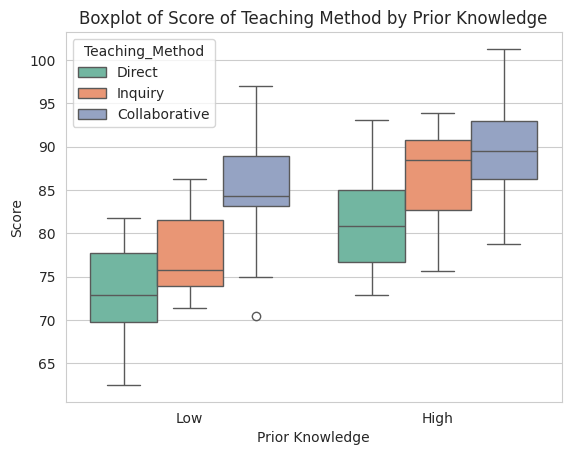

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

teaching = pd.read_excel('Data Science Teaching Method.xlsx')

print(teaching.info())

sum_stats = teaching.groupby(['Prior_Knowledge', 'Teaching_Method'])['Score'].agg(['mean', 'std'])
print(sum_stats)


#Specify order

knowledge_order = ['Low', 'High']

teaching['Prior_Knowledge'] = pd.Categorical(teaching['Prior_Knowledge'], categories=knowledge_order, ordered=True)

## Step 2: Create the boxplot using seaborn.
## We use the `order` and `hue_order` parameters to ensure the correct order.

sns.set_style("whitegrid")

sns.boxplot(
    data = teaching,
    x = 'Prior_Knowledge',
    y = 'Score',
    hue = 'Teaching_Method',
    palette = 'Set2'
)

plt.title('Boxplot of Score of Teaching Method by Prior Knowledge')
plt.xlabel('Prior Knowledge')
plt.ylabel('Score')

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

*Based on the visual & testing method results, the results support the assumption of normality. The p-value is greater than 0.05, which means that we fail to reject the null hypothesis that the residuals are normally distributed. Also, the QQ plot shows that the dots, for the most part, all fall near the diagnol line, further confirming assumption of normality.*

In [6]:
teaching.rename(columns={"Teaching Method": "Teaching_Method","Prior Knowledge": "Prior_Knowledge"}, inplace=True)


ex_mod = ols("Score ~ Teaching_Method + Prior_Knowledge", data=teaching).fit()

# ANOVA table
ex_tab = sm.stats.anova_lm(ex_mod,typ=3)


## Add Significance Column ##
ex_tab["Significance"] = np.where(ex_tab["PR(>F)"]<0.05,"Significant","Not Significant")


# Print only Teaching and Knowledge rows
print(ex_tab.loc[["Teaching_Method","Prior_Knowledge"]])

                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant


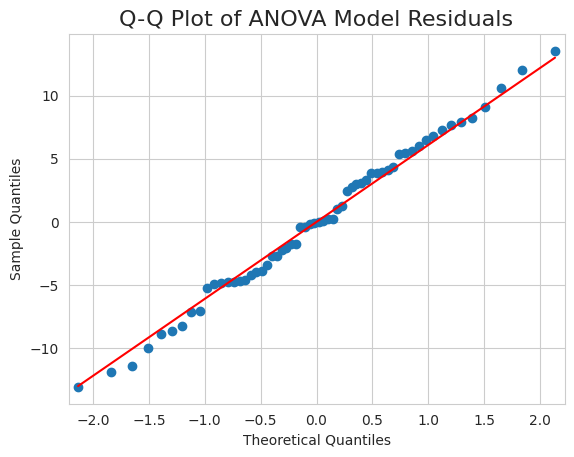

Shapiro-Wilk Test Statistic: 0.9893
Shapiro-Wilk Test P-Value: 0.8794
The residuals are normally distributed (fail to reject H0).


In [7]:
## Import scipy ##
import scipy.stats as stats

## Extract Model Residuals ##
ex_residuals = ex_mod.resid

## Generate QQ plot using seaborn ##
sm.qqplot(ex_residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals", fontsize=16)
plt.show()

## Perform Shapiro-Wilk Test ##
shapiro_test = stats.shapiro(ex_residuals)
## Get Test Stat ##
shapiro_stat = shapiro_test.statistic
## Get P-Value ##
shapiro_pvalue = shapiro_test.pvalue
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {shapiro_pvalue:.4f}")
if shapiro_pvalue < 0.05:
    print("The residuals are not normally distributed (reject H0).")
else:
    print("The residuals are normally distributed (fail to reject H0).")

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

*Based on the fact that there are no values greater than 3 or less than -3, and based on the fact that our p-value is much greater than 0.05, this means that the there is no heteroscedascity detected, and that we fail to reject the hull hypothesis. This also means that constant variance can be assumed.*

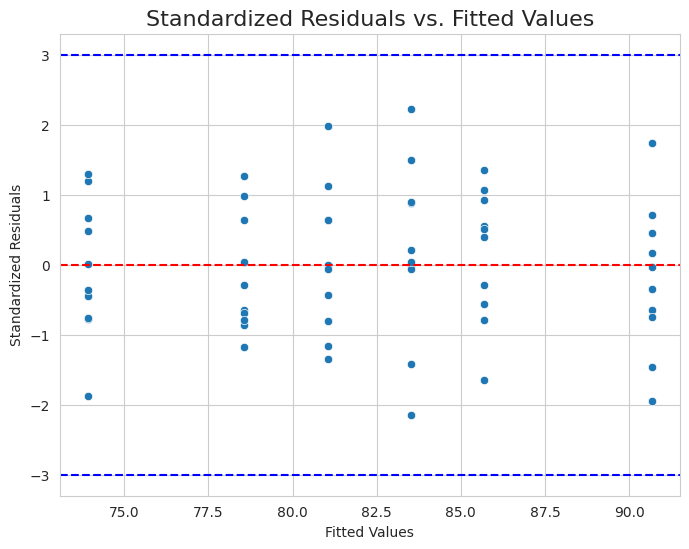

F-statistic: 0.7579465871345092
F p-value: 0.5224437459616427
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [8]:
## Obtain Standardized Residuals ##
standardized_residuals = ex_mod.get_influence().resid_studentized_internal

## Get the fitted values ##
fitted_values = ex_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()


## B-P Test ##
## Import necessary function: ##
from statsmodels.stats.diagnostic import het_breuschpagan


## Run B-P Test ##
bp_test = het_breuschpagan(ex_mod.resid,ex_mod.model.exog)


## Extract F-statistic ##
f_statistic = bp_test[2]


## Extract its P-Value ##
f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

*The f-statistic is equal to 11.63 and the p-value is lower than 0.05. This indicates a stronger lean toward the alternative hypothesis. And since the p-value is less than 0.05, we reject the null hypothesis that all of the percentage scores are the same.*

In [9]:
print(ex_tab.loc[["Teaching_Method","Prior_Knowledge"]])

                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

*The results indicate that the mean percentage scores between the collaborative and direct teaching method are statistically different from each other. However, the mean percentage scors between the collaborative & inquiry and the direct & inquiry teaching methods are not found to be statistically different from each other.*

Figure(1000x600)
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
    group1     group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Collaborative  Direct  -9.6085 0.0003 -15.1184 -4.0986   True
Collaborative Inquiry  -4.9855 0.0838 -10.4954  0.5244  False
       Direct Inquiry    4.623 0.1168  -0.8869 10.1329  False
-------------------------------------------------------------


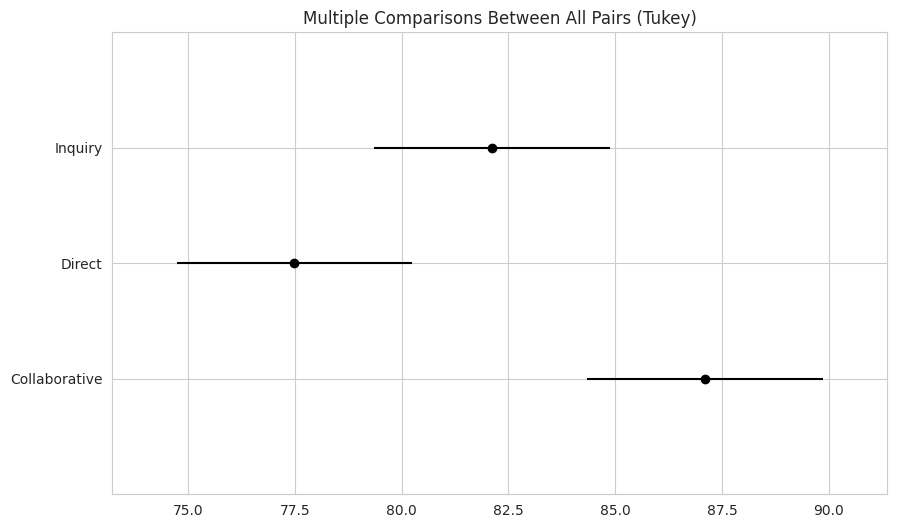

In [11]:
## Import pairwise_tukeyhsd function ##
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(endog=teaching['Score'], groups=teaching['Teaching_Method'],
                                  alpha=0.05)

## Print Tukey Visualization ##
print(tukey_result.plot_simultaneous())

print(tukey_result)

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.

*Based on the results, at least one mean percentage score is shown to be different from the rest of them, meaning that at least the directive, inquiring, or collaborative teaching methods yielded different mean percentages from one another. This is backed up by the high f-statistic and the p-value lower than 0.05. Now, based on the boxplot, it seems as though the collaborative boxplot yielded the highest percentage scores, both among the students who had prior knowledge of hypothesis testing, and among those who did not. That being said, there is not a statistical difference in scores between the collaborative & inquiry method and the direct & inquiry method.*

**PART 2 INSTRUCTIONS**: Now suppose a university is evaluating the effectiveness of four different online learning platforms (say A, B, C, and D) on student engagement for students taking an undergraduate data science course in an online synchronous format. One section of the course is offered Monday through Thursday in the Morning, Early Afternoon, Mid-Afternoon, and Evening sections. Student engagement is measured through the total number of logins to the online learning platform for a given course section over the course of the
semester. Below is a table describing the study design and factors:


| Section \ Day     | Monday | Tuesday | Wednesday | Thursday |
|-------------------|--------|---------|-----------|----------|
| **Morning**       | A      | B       | C         | D        |
| **Early Afternoon** | B      | C       | D         | A        |
| **Mid-Afternoon** | C      | D       | A         | B        |
| **Evening**       | D      | A       | B         | C        |


Here, our main interest is in comparing engagement across the online learning platforms, but we also want to control for Day of the Week as well as Time of Day, as these could potentially be confounding variables. The data for this experiment are contained in the `Online Learning and Engagement.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

*We are interested in comparing the mean student engagement across the four online learning platforms (treatment effect), controlling for the day of the week & the time of day*

**Question 2.** Specify the outcome variable

*Our outcome variable will be the total number of logins to the online learning platforms. This is a quantitative, discrete variable*

**Question 3.** Specify the independent variable and blocking factors. What are some other possible lurking variables?

*The independent variable is the type of online learning platform (a categorical variable), which are separated by four levels, or four different platforms. The blocking factors include the time of day and the day of the week, which are both categorical variables. Lurking variables may include the number of clubs/organizations the student is involved in (quantitative), their major (because the question doesn't specify if these students are actual data science majors), which would be categorical.*

**Question 4.** Briefly explain why a Latin Square Design would be appropriate here. Similarly, explain why a completely randomized design or randomized block design would not be appropriate.

*A latin square design would be appropriate due to the fact that we have more than one block factor. A completely randomized design does not account for any block factors, which runs the risk of lack of homogeniety among the experimental units. A randomized block design only accounts for one block factor, and doesn't take into account if there are other lurking variables that may need to be "blocked" to prevent too much variation and keep experimental units homogenous.*

**Question 5.** State the null and alternative hypotheses for this experiment.

*H0: The mean engagement among the four different online platforms are the same*

*HA: At least two mean among the four different online platforms is different from the rest*

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

*Based on the summary statistics and data visualizations, the results more strongly support the alternative hypothesis.*

In [12]:
from google.colab import files
uploaded = files.upload()

Saving Online Learning and Engagement.xlsx to Online Learning and Engagement.xlsx


In [14]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# import data
online = pd.read_excel('Online Learning and Engagement.xlsx')

## Data Integrity Check ##
print(online.info())

sum_stats = online.groupby(['Platform'])['Engagement'].agg(['mean', 'std'])
print(sum_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Day         16 non-null     object 
 1   Section     16 non-null     object 
 2   Platform    16 non-null     object 
 3   Engagement  16 non-null     float64
dtypes: float64(1), object(3)
memory usage: 644.0+ bytes
None
               mean        std
Platform                      
A         1408.8475  19.319733
B         1339.7200  39.845434
C         1332.6425  32.288451
D         1379.0225   7.354601


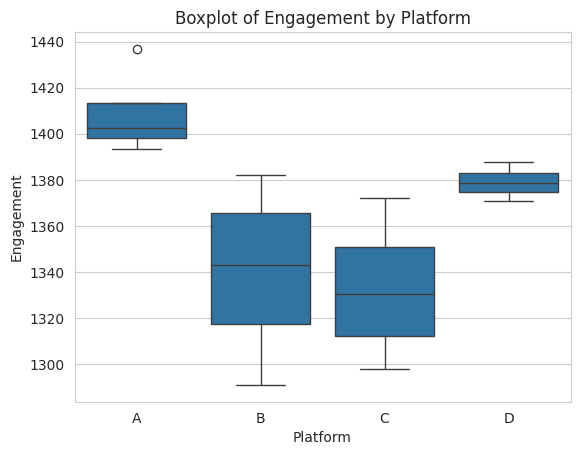

In [15]:
## Build a Boxplot ##
## Set up style ##
sns.set_style("whitegrid")

sns.boxplot(
    data=online,
    x='Platform',
    y='Engagement'
)

plt.title('Boxplot of Engagement by Platform')
plt.xlabel('Platform')
plt.ylabel('Engagement')

plt.show()

**Question 7.** Build a three-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

*The QQ plot displayed shows that most of the dots fall along the diagnol line. Also, the p-value is above 0.05. This means we fail to reject the null hypothesis that the residuals appear to be normally distributed*

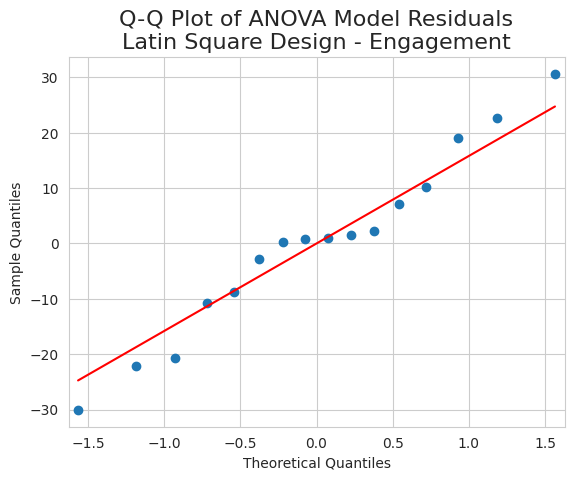

Shapiro-Wilk Test Statistic: 0.9727, p-value: 0.8797
✅ Residuals appear to be normally distributed (fail to reject H0).


In [17]:
lsd_mod = ols("Engagement ~ Platform + Day + Section", data=online).fit()

residuals = lsd_mod.resid

sm.qqplot(residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals\nLatin Square Design - Engagement",
          loc='center',
          fontsize=16)
plt.show()

sw = stats.shapiro(residuals)

sw_stat = sw.statistic
sw_pval = sw.pvalue
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}, p-value: {sw_pval:.4f}")
if sw_pval > 0.05:
    print("✅ Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("❌ Residuals do not appear to be normally distributed (reject H0).")

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

*Based on the p-value, which is higher than 0.05, this means that we fail to reject the null hypothesis that the residuals have a constant variance. Furthermore, the residuals are all within the -3 and 3 lines, further confirming homogeneity of variance*

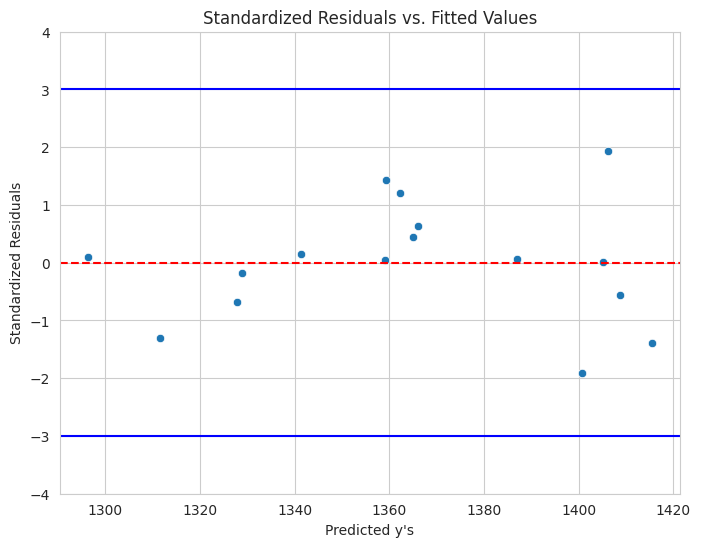

F-statistic: 1.0496262780133732
F p-value: 0.49513363026521795
✅ Residuals appear to have constant variance (fail to reject H0).


In [18]:
standardized_residuals = lsd_mod.get_influence().resid_studentized_internal

fitted_values = lsd_mod.fittedvalues

## Create the plot ##
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

## B-P Test ##

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(lsd_mod.resid,lsd_mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value > 0.05:
    print("✅ Residuals appear to have constant variance (fail to reject H0).")
else:
    print("❌ Residuals do not appear to have constant variance (reject H0).")


**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

*Focusing on our main effect, the Platform, based on the p-value being smaller than 0.05 and the F-statistic being relatively large, we reject the null hypothesis that the mean engagement among the different platforms is the same.*

In [20]:
## Print ANOVA Table ##
lsd_tab = sm.stats.anova_lm(lsd_mod,typ=3)
## Add Significance Column ##
lsd_tab['Sig'] = np.where(lsd_tab['PR(>F)']<0.05,'Yes','No')
## Print only the main effect and blocking factor rows ##
print(lsd_tab.loc[['Platform','Day','Section']])

                sum_sq   df         F    PR(>F)  Sig
Platform  15221.225819  3.0  7.607701  0.018122  Yes
Day        2774.676069  3.0  1.386807  0.334557   No
Section    2396.427869  3.0  1.197756  0.387569   No


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

*Based on the Tukey plot, this shows that all of the groupings except for the one between A & B and A & C are not meaningfully significantly different from one another*

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     A      B -69.1275 0.0186 -127.1688 -11.0862   True
     A      C  -76.205 0.0099 -134.2463 -18.1637   True
     A      D  -29.825 0.4534  -87.8663  28.2163  False
     B      C  -7.0775  0.983  -65.1188  50.9638  False
     B      D  39.3025 0.2375  -18.7388  97.3438  False
     C      D    46.38 0.1359  -11.6613 104.4213  False
-------------------------------------------------------


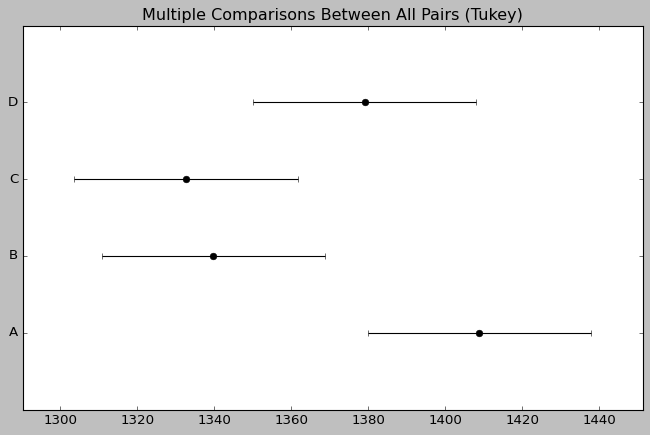

In [21]:
tukey_result = pairwise_tukeyhsd(endog=online['Engagement'], groups=online['Platform'], alpha = 0.05)

tukey_result.plot_simultaneous()

print(tukey_result)

**Question 11.** Write a brief conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.

*Based on the p-value being lower than 0.05 and the F-statistic from the ANOVA table, this means that the alternative hypothesis is strongly support, which is that at least two of the mean engagements from the four online platforms are different from the rest. All of the groupings except for the one between A & B and A & C are not meaningfully significantly different from one anotherIt seems that online platform A has the highest engagement.  There is both normality and homogenity among the residuals.*